# Spaceship Titanic Attempt Nr 2

In [29]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn import tree, ensemble, svm
from xgboost import XGBClassifier

from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_validate, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


In [30]:
data_train = pd.read_csv('data/train.csv')
data_test = pd.read_csv('data/test.csv')

data_train["train_test"] = True
data_test["train_test"] = False

data_merged = pd.concat([data_train, data_test], axis=0, ignore_index=True)

In [31]:
data_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  object 
 1   HomePlanet    12682 non-null  object 
 2   CryoSleep     12660 non-null  object 
 3   Cabin         12671 non-null  object 
 4   Destination   12696 non-null  object 
 5   Age           12700 non-null  float64
 6   VIP           12674 non-null  object 
 7   RoomService   12707 non-null  float64
 8   FoodCourt     12681 non-null  float64
 9   ShoppingMall  12664 non-null  float64
 10  Spa           12686 non-null  float64
 11  VRDeck        12702 non-null  float64
 12  Name          12676 non-null  object 
 13  Transported   8693 non-null   object 
 14  train_test    12970 non-null  bool   
dtypes: bool(1), float64(6), object(8)
memory usage: 1.4+ MB


In [32]:
data_merged.isnull().sum()

PassengerId        0
HomePlanet       288
CryoSleep        310
Cabin            299
Destination      274
Age              270
VIP              296
RoomService      263
FoodCourt        289
ShoppingMall     306
Spa              284
VRDeck           268
Name             294
Transported     4277
train_test         0
dtype: int64

In [33]:
# splitting Cabin into three columns to see whether parts of the ship were more likely to survive
data_merged[['cabin_deck', 'cabin_num', 'cabin_side']] = data_merged['Cabin'].str.split('/', expand=True)


# assuming no spending means no service used
column_spending = ['RoomService','FoodCourt','Spa','ShoppingMall','VRDeck']
data_merged[column_spending] = data_merged[column_spending].fillna(0)
data_merged['Spending'] = data_merged['RoomService'] + data_merged['FoodCourt'] + data_merged['Spa'] + data_merged['ShoppingMall'] + data_merged['VRDeck']


In [34]:
data_merged.isnull().sum()

PassengerId        0
HomePlanet       288
CryoSleep        310
Cabin            299
Destination      274
Age              270
VIP              296
RoomService        0
FoodCourt          0
ShoppingMall       0
Spa                0
VRDeck             0
Name             294
Transported     4277
train_test         0
cabin_deck       299
cabin_num        299
cabin_side       299
Spending           0
dtype: int64

In [35]:
column_numerical = ["ShoppingMall", "FoodCourt", "RoomService", "Spa", "VRDeck", "Spending", "Age"]
column_categorical = ["CryoSleep", "cabin_deck", "cabin_side", "VIP", "HomePlanet", "Destination"]

In [36]:
imputer_numerical = SimpleImputer(strategy='mean')
data_merged[column_numerical] = imputer_numerical.fit_transform(data_merged[column_numerical])

imputer_categorical = SimpleImputer(strategy='most_frequent')
data_merged[column_categorical] = imputer_categorical.fit_transform(data_merged[column_categorical])

encoder_onehot= OneHotEncoder(handle_unknown='ignore', sparse_output=False)
data_merged_encoded = pd.DataFrame(encoder_onehot.fit_transform(data_merged[column_categorical]), columns=encoder_onehot.get_feature_names_out(), index=data_merged.index)

data_merged = pd.concat([data_merged[column_numerical], data_merged_encoded, data_merged[["train_test", "Transported"]]], axis=1)

data_merged

,ShoppingMall,FoodCourt,RoomService,Spa,VRDeck,Spending,Age,CryoSleep_False,CryoSleep_True,cabin_deck_A,...,VIP_False,VIP_True,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,train_test,Transported
0,0.0,0.0,0.0,0.0,0.0,0.0,39.000000,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,True,False
1,25.0,9.0,109.0,549.0,44.0,736.0,24.000000,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,True,True
2,0.0,3576.0,43.0,6715.0,49.0,10383.0,58.000000,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,True,False
3,371.0,1283.0,0.0,3329.0,193.0,5176.0,33.000000,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,True,False
4,151.0,70.0,303.0,565.0,2.0,1091.0,16.000000,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,0.0,0.0,0.0,0.0,0.0,0.0,34.000000,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,False,NaN
12966,17.0,847.0,0.0,10.0,144.0,1018.0,42.000000,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,False,NaN
12967,0.0,0.0,0.0,0.0,0.0,0.0,28.771969,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,False,NaN
12968,0.0,2680.0,0.0,0.0,523.0,3203.0,28.771969,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,False,NaN


In [37]:
data_xtrain = data_merged[data_merged["train_test"] == True].drop(['Transported', 'train_test'], axis=1)
data_ytrain = data_merged[data_merged["train_test"] == True]['Transported'].astype(bool)

data_xtest = data_merged[data_merged["train_test"] == False].drop(['Transported', 'train_test'], axis=1)

In [38]:
MLA = [
    ensemble.RandomForestClassifier(),
    svm.SVC(probability=True),
    tree.DecisionTreeClassifier(),
    XGBClassifier()
]

strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MLA_columns = ['MLA Name', 'MLA Parameters','MLA Train Accuracy Mean', 'MLA Test Accuracy Mean', 'MLA Time']
MLA_compare = pd.DataFrame(columns = MLA_columns)

fitted_models = {}

row_index = 0
for alg in MLA:

    MLA_name = alg.__class__.__name__
    MLA_compare.loc[row_index, 'MLA Name'] = MLA_name
    MLA_compare.loc[row_index, 'MLA Parameters'] = str(alg.get_params())

    cv_results = cross_validate(alg, data_xtrain, data_ytrain, cv=strat_kfold, return_train_score=True, n_jobs=7)

    MLA_compare.loc[row_index, 'MLA Time'] = cv_results['fit_time'].mean()
    MLA_compare.loc[row_index, 'MLA Train Accuracy Mean'] = cv_results['train_score'].mean()
    MLA_compare.loc[row_index, 'MLA Test Accuracy Mean'] = cv_results['test_score'].mean()   

    #save MLA predictions - see section 6 for usage
    alg.fit(data_xtrain, data_ytrain)
    fitted_models[MLA_name] = alg
    row_index+=1

#print and sort table: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.sort_values.html
MLA_compare.sort_values(by = ['MLA Test Accuracy Mean'], ascending = False, inplace = True)
MLA_compare

,MLA Name,MLA Parameters,MLA Train Accuracy Mean,MLA Test Accuracy Mean,MLA Time
3,XGBClassifier,"{'objective': 'binary:logistic', 'base_score':...",0.910503,0.797539,0.255129
0,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.949241,0.791671,1.261128
1,SVC,"{'C': 1.0, 'break_ties': False, 'cache_size': ...",0.79055,0.78845,10.425427
2,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit...",0.949298,0.745543,0.052001


Text(0, 0.5, 'Algorithm')

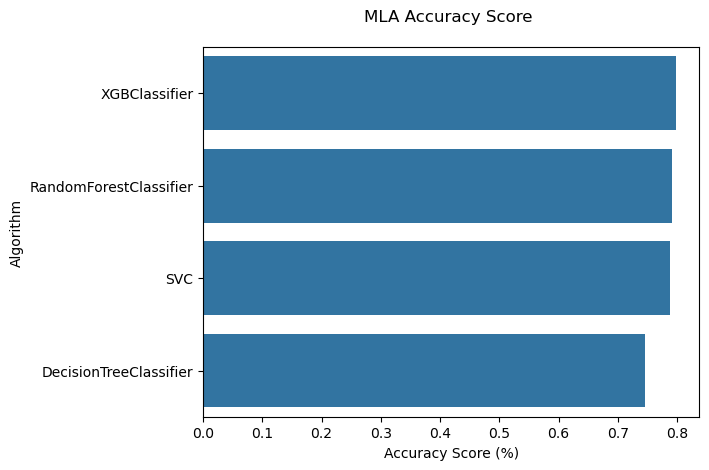

In [39]:
sns.barplot(x='MLA Test Accuracy Mean', y = 'MLA Name', data = MLA_compare)
plt.title('MLA Accuracy Score \n')
plt.xlabel('Accuracy Score (%)')
plt.ylabel('Algorithm')

### Baseline Submission

In [40]:
submission = pd.DataFrame()
svc_model = fitted_models.get("XGBClassifier")
submission["PassengerId"] = data_test["PassengerId"]
submission["Transported"] = svc_model.predict(data_xtest).astype(bool)

submission.to_csv("./results/v2_baseline_xgb_submission.csv", index=False)

# 0.79845

In [41]:
MLA_optim = [
    ensemble.RandomForestClassifier(),
    #svm.SVC(probability=True),
    tree.DecisionTreeClassifier(),
    XGBClassifier()
]

param_grid_rf = {
    'n_estimators': [ 100, 150, 200,250, 300],
    'max_leaf_nodes' : [50,100,150,200],
    'min_samples_leaf': [1, 4, 7],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

# param_grid_svc = {
#     'C': [0.1, 1, 10],
#     'kernel': ['linear', 'rbf'],
#     'gamma': ['scale']
# }
param_grid_dt = {
    'max_leaf_nodes' : [100,150,200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 4, 7],
    'criterion': ['gini', 'entropy', 'log_loss']  # 'log_loss' for classifier with probabilistic output
}
param_grid_xgb = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.075, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'random_state': [42]
}
MLA_optim_grid = [
    param_grid_rf,  param_grid_dt, param_grid_xgb
]

# set MLA's which should use RandomizedSearchCV instead of GridSearch (slow algo or big param space)
MLA_randomizedSearch = ["XGBClassifier"]

strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MLA_optim_columns = ['MLA Name', 'MLA Parameters','MLA Train Accuracy Mean', 'MLA Train Improvement','MLA Test Accuracy Mean', 'MLA Test Improvement', 'MLA Time']
MLA_optim_compare = pd.DataFrame(columns = MLA_optim_columns)

optimize_fitted_models = {}
row_index = 0

for idx, alg in enumerate(MLA_optim):
    MLA_name = alg.__class__.__name__
    MLA_optim_compare.loc[row_index, 'MLA Name'] = MLA_name
    print('-' * 50)
    print(MLA_name)

    if MLA_name in MLA_randomizedSearch:
        gridSearch_result = RandomizedSearchCV(alg, param_distributions=MLA_optim_grid[idx], cv=strat_kfold, n_iter=100 ,verbose=10, n_jobs=6, return_train_score=True)
    else:
        gridSearch_result = GridSearchCV(alg, param_grid=MLA_optim_grid[idx], cv=strat_kfold, verbose=10, n_jobs=6, return_train_score=True)
    gridSearch_result.fit(data_xtrain, data_ytrain)

    # get correlation row from baseline model
    row_index_compare = MLA_compare[MLA_compare['MLA Name'] == alg.__class__.__name__].index[0]

    MLA_optim_compare.loc[row_index, 'MLA Parameters'] = str(gridSearch_result.best_params_)
    MLA_optim_compare.loc[row_index, 'MLA Time'] = gridSearch_result.cv_results_['mean_fit_time'][gridSearch_result.best_index_]
    
    mean_train_score = gridSearch_result.cv_results_['mean_train_score'][gridSearch_result.best_index_]
    MLA_optim_compare.loc[row_index, 'MLA Train Accuracy Mean'] = mean_train_score
    MLA_optim_compare.loc[row_index, 'MLA Train Improvement'] = mean_train_score - MLA_compare.iloc[row_index_compare, 2]

    mean_test_score = gridSearch_result.cv_results_['mean_test_score'][gridSearch_result.best_index_] 
    MLA_optim_compare.loc[row_index, 'MLA Test Accuracy Mean'] = mean_test_score
    MLA_optim_compare.loc[row_index, 'MLA Test Improvement'] = mean_test_score - MLA_compare.iloc[row_index_compare, 3]

    optimize_fitted_models[MLA_name] = gridSearch_result.best_estimator_
    row_index+=1


MLA_optim_compare.sort_values(by = ['MLA Test Accuracy Mean'], ascending = False, inplace = True)
MLA_optim_compare

--------------------------------------------------
RandomForestClassifier
Fitting 5 folds for each of 480 candidates, totalling 2400 fits
[CV 1/5; 1/480] START bootstrap=True, criterion=gini, max_features=sqrt, max_leaf_nodes=50, min_samples_leaf=1, n_estimators=100
[CV 2/5; 1/480] START bootstrap=True, criterion=gini, max_features=sqrt, max_leaf_nodes=50, min_samples_leaf=1, n_estimators=100
[CV 3/5; 1/480] START bootstrap=True, criterion=gini, max_features=sqrt, max_leaf_nodes=50, min_samples_leaf=1, n_estimators=100
[CV 5/5; 1/480] START bootstrap=True, criterion=gini, max_features=sqrt, max_leaf_nodes=50, min_samples_leaf=1, n_estimators=100
[CV 1/5; 2/480] START bootstrap=True, criterion=gini, max_features=sqrt, max_leaf_nodes=50, min_samples_leaf=1, n_estimators=150
[CV 4/5; 1/480] START bootstrap=True, criterion=gini, max_features=sqrt, max_leaf_nodes=50, min_samples_leaf=1, n_estimators=100
[CV 2/5; 1/480] END bootstrap=True, criterion=gini, max_features=sqrt, max_leaf_nodes=50

,MLA Name,MLA Parameters,MLA Train Accuracy Mean,MLA Train Improvement,MLA Test Accuracy Mean,MLA Test Improvement,MLA Time
2,XGBClassifier,"{'subsample': 1.0, 'random_state': 42, 'n_esti...",0.839727,-0.109571,0.808237,0.062694,0.308287
0,RandomForestClassifier,"{'bootstrap': True, 'criterion': 'entropy', 'm...",0.833113,-0.07739,0.804324,0.006785,0.993559
1,DecisionTreeClassifier,"{'criterion': 'gini', 'max_depth': 10, 'max_le...",0.833142,0.042592,0.79213,0.00368,0.031968


Text(0, 0.5, 'Algorithm')

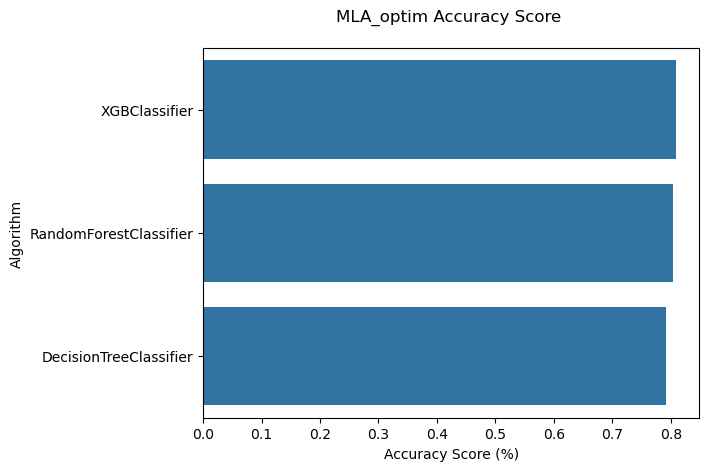

In [42]:
sns.barplot(x='MLA Test Accuracy Mean', y = 'MLA Name', data = MLA_optim_compare)
plt.title('MLA_optim Accuracy Score \n')
plt.xlabel('Accuracy Score (%)')
plt.ylabel('Algorithm')

In [43]:
submission = pd.DataFrame()
svc_model = optimize_fitted_models.get("XGBClassifier")
submission["PassengerId"] = data_test["PassengerId"]
submission["Transported"] = svc_model.predict(data_xtest).astype(bool)

submission.to_csv("./results/v2_optim_xgb_submission.csv", index=False)
# 0.80196

In [44]:
voter_xgb = optimize_fitted_models['XGBClassifier']
voter_rf = optimize_fitted_models['RandomForestClassifier']
voter_dt = optimize_fitted_models['DecisionTreeClassifier']

### Hard Voting Ensemble: 0.79915

In [45]:


submission = pd.DataFrame()
submission["PassengerId"] = data_test["PassengerId"]
prediction_hard = np.array(
    voter_xgb.predict(data_xtest) + 
    voter_rf.predict(data_xtest) +
    voter_dt.predict(data_xtest)
)
submission["Transported"] = prediction_hard >= 2

submission.to_csv("./results/v2_manual_hard_ensemble_submission.csv", index=False)

In [46]:
submission = pd.DataFrame()
submission["PassengerId"] = data_test["PassengerId"]
probs_test = np.array([
    voter_xgb.predict_proba(data_xtest),
    voter_rf.predict_proba(data_xtest),
    voter_dt.predict_proba(data_xtest)
])
avg_probs_test = np.mean(probs_test, axis=0)
submission["Transported"] = np.argmax(avg_probs_test, axis=1).astype(bool)

submission.to_csv("./results/v2_manual_soft_ensemble_submission.csv", index=False)